# Neural-EM — Dynamic Training (Colab)
Entrainement sur sequences temporelles `flying_mnist_hard_3digits.h5`
avec le modele Neural Expectation-Maximization (Greff et al., 2017).

In [1]:
# 1. Verifier le GPU disponible
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'Pas de GPU NVIDIA detecte')

Sun Mar  1 13:41:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Cloner le repo (branche develop) ou mettre a jour si deja present
import os

if os.path.exists('/content/Neural-E-M-'):
    %cd /content/Neural-E-M-
    !git pull origin develop
else:
    !git clone -b develop https://github.com/MarouaneAEF/Neural-E-M-.git
    %cd /content/Neural-E-M-

Cloning into 'Neural-E-M-'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 371 (delta 85), reused 108 (delta 46), pack-reused 218 (from 1)
Receiving objects: 100% (371/371), 140.46 KiB | 1.18 MiB/s, done.
Resolving deltas: 100% (230/230), done.
/content/Neural-E-M-


In [3]:
# 3. Vider le cache des modules pour forcer le rechargement depuis le disque
import sys

for mod in ['sequential_dataloader', 'q_graph', 'rnn_em_cell_bernoulli',
            'bernoulli_loss', 'util']:
    if mod in sys.modules:
        del sys.modules[mod]

print('Cache modules vide.')

Cache modules vide.


In [4]:
# 3. Installer les dependances manquantes
!pip install -q scikit-learn h5py matplotlib

In [5]:
# 4. Telecharger les donnees depuis Dropbox
import os
os.makedirs('./data', exist_ok=True)

print('Telechargement du dataset depuis Dropbox...')
!wget -q --show-progress -O ./data.zip \
    "https://www.dropbox.com/sh/1ue3lrfvbhhkt6s/AAB6WiZzH_mAtCjW6b9okMGea?dl=1"

print('Extraction...')
!unzip -q ./data.zip -d ./data
!rm ./data.zip

print('Fichiers disponibles :')
!ls -lh ./data/*.h5

Telechargement du dataset depuis Dropbox...
./data.zip          100%[===================>]   7.17G  84.2MB/s    in 92s     
Extraction...
mapname:  conversion of  failed
Fichiers disponibles :
-rwxr--r-- 1 root root 1.6G Aug 10  2017 ./data/flying_mnist_hard_2digits_51.h5
-rwxr--r-- 1 root root 775M Aug 10  2017 ./data/flying_mnist_hard_2digits.h5
-rwxr--r-- 1 root root 1.2G Aug 10  2017 ./data/flying_mnist_hard_3digits.h5
-rwxr--r-- 1 root root 526M Aug 10  2017 ./data/flying_mnist_medium20_2digits.h5
-rwxr--r-- 1 root root 752M Aug 10  2017 ./data/flying_mnist_medium500_2digits.h5
-rwxr--r-- 1 root root 851M Aug 10  2017 ./data/flying_shapes_4.h5
-rwxr--r-- 1 root root 1.1G Aug 10  2017 ./data/flying_shapes_5.h5
-rwxr--r-- 1 root root 596M Aug 10  2017 ./data/flying_shapes.h5
-rwxr--r-- 1 root root  34M Aug 10  2017 ./data/mnist_2digits_downsampled.h5
-rwxr--r-- 1 root root  26M Aug 10  2017 ./data/shapes.h5


In [6]:
# 5. Verifier la structure du dataset dynamique
import h5py
with h5py.File('./data/flying_mnist_hard_3digits.h5', 'r') as f:
    for split in f.keys():
        feat_shape  = f[split]['features'].shape
        group_shape = f[split]['groups'].shape
        print(f'{split}: features={feat_shape}, groups={group_shape}')

test: features=(25, 10000, 24, 24, 1), groups=(25, 10000, 24, 24, 1)
training: features=(25, 50000, 24, 24, 1), groups=(25, 50000, 24, 24, 1)
validation: features=(25, 10000, 24, 24, 1), groups=(25, 10000, 24, 24, 1)


In [7]:
# 6. Configuration TensorFlow pour GPU CUDA
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f'GPU : {physical_devices[0].name}')
    print(f'TensorFlow : {tf.__version__}')
else:
    print('Aucun GPU — verifier Runtime > Changer le type de runtime > GPU')

GPU : /physical_device:GPU:0
TensorFlow : 2.19.0


In [8]:
# 7. Imports et configuration
import gc
import numpy as np
import matplotlib.pyplot as plt
import datetime
import time
from tensorflow.keras.metrics import Mean

from rnn_em_cell_bernoulli import rnn_em
from q_graph import Q_graph
from sequential_dataloader import get_dataset, generator, BATCH_SIZE, SEQUENCE_LENGTH
from util import bitflip_noisy_static, ami_score
from bernoulli_loss import em_loss

K          = 3
LSTM_UNITS = 64
IMAGE_SIZE = 24   # flying_mnist images are 24x24

print(f'BATCH_SIZE      = {BATCH_SIZE}')
print(f'SEQUENCE_LENGTH = {SEQUENCE_LENGTH}')
print(f'IMAGE_SIZE      = {IMAGE_SIZE}')
print(f'K               = {K}')

BATCH_SIZE      = 8
SEQUENCE_LENGTH = 21
IMAGE_SIZE      = 24
K               = 3


In [9]:
# 8. Smoke test du dataloader
train_data = get_dataset(generator, 'training')
valid_data = get_dataset(generator, 'validation')

for features, groups in train_data.take(1):
    print(f'features : {features.shape}')   # attendu (8, 21, 24, 24, 1)
    print(f'groups   : {groups.shape}')     # attendu (8, 21, 24, 24, 1)
    print(f'range    : [{features.numpy().min():.3f}, {features.numpy().max():.3f}]')

features : (8, 21, 24, 24, 1)
groups   : (8, 21, 24, 24, 1)
range    : [0.000, 1.000]


In [10]:
# 9. Initialisation du modele et des checkpoints
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True)

optimizer  = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
inner_cell = Q_graph(image_size=IMAGE_SIZE)
loss_fn    = em_loss(initial_kl_weight=0.01, max_kl_weight=0.3, annealing_rate=0.001)
rnn_cell   = rnn_em(inner_cell, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

os.makedirs('./logs', exist_ok=True)
os.makedirs('./plots_dynamic', exist_ok=True)

checkpoint = tf.train.Checkpoint(
    step=tf.Variable(0, dtype=tf.int64),
    ami=tf.Variable(-1e10),
    optimizer=optimizer,
    model=rnn_cell.model)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, './ckpt/dynamic', max_to_keep=3)

current_time   = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
summary_writer = tf.summary.create_file_writer(f'./logs/dynamic_{current_time}')

print('Modele initialise.')

Modele initialise.


In [11]:
# 10. Train step et utilitaires

def visualize_clusters(gamma, features, epoch, step):
    cluster_assignments = tf.argmax(gamma, axis=1)
    sample_img          = features[0, 0, :, :, 0].numpy()
    sample_assignment   = cluster_assignments[0, :, :, 0].numpy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(sample_img, cmap='gray')
    ax1.set_title('Frame 0 - Original')
    ax1.axis('off')
    cmap = plt.cm.get_cmap('viridis', K)
    ax2.imshow(sample_assignment, cmap=cmap, vmin=0, vmax=K - 1)
    ax2.set_title('Cluster Assignments')
    ax2.axis('off')
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
    plt.tight_layout()
    plt.savefig(f'./plots_dynamic/clusters_epoch{epoch}_step{step}.png')
    plt.show()
    plt.close()


N_EM_ITERATIONS = 15

@tf.function(input_signature=[
    tf.TensorSpec(shape=(BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(BATCH_SIZE * K, LSTM_UNITS), dtype=tf.float32),
    tf.TensorSpec(shape=(BATCH_SIZE * K, LSTM_UNITS), dtype=tf.float32),
    tf.TensorSpec(shape=(BATCH_SIZE, K, IMAGE_SIZE, IMAGE_SIZE, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(BATCH_SIZE, K, IMAGE_SIZE, IMAGE_SIZE, 1), dtype=tf.float32),
])
def train_step_frame(frame, lstm_h, lstm_c, preds, gamma):
    frame_noisy  = bitflip_noisy_static(frame)
    hidden_state = ([lstm_h, lstm_c], preds, gamma)
    current_lr   = lr_schedule(optimizer.iterations)
    for _ in range(N_EM_ITERATIONS):
        with tf.GradientTape() as tape:
            hidden_state = rnn_cell((frame_noisy, frame), hidden_state)
            rnn_state_new, preds_new, gamma_new = hidden_state
            loss = loss_fn(preds_new, frame, gamma_new)
        grads = tape.gradient(loss, rnn_cell.model.trainable_weights)
        grads = [tf.clip_by_norm(g, 3.0) if g is not None else g for g in grads]
        optimizer.apply_gradients(zip(grads, rnn_cell.model.trainable_weights))
    return loss, rnn_state_new[0], rnn_state_new[1], preds_new, gamma_new, current_lr


def make_initial_state():
    lstm_h = tf.zeros([BATCH_SIZE * K, LSTM_UNITS])
    lstm_c = tf.zeros([BATCH_SIZE * K, LSTM_UNITS])
    _, preds, gamma = rnn_cell.initial_state(BATCH_SIZE, K)
    return lstm_h, lstm_c, preds, gamma


def validation(dataset):
    ami_values = []
    for features, groups in dataset:
        lstm_h, lstm_c, preds, gamma = make_initial_state()
        for t in range(SEQUENCE_LENGTH):
            frame_t      = features[:, t:t + 1, :, :, :]
            frame_noisy  = bitflip_noisy_static(frame_t)
            hidden_state = ([lstm_h, lstm_c], preds, gamma)
            hidden_state = rnn_cell((frame_noisy, frame_t), hidden_state)
            (lstm_h, lstm_c), preds, gamma = hidden_state[0], hidden_state[1], hidden_state[2]
        ami_values.append(ami_score(gamma, groups[:, -1:, :, :, :]))
    return tf.reduce_mean(ami_values)


print('Fonctions compilees.')

Fonctions compilees.


Epoch 1 | Step 1 | loss=1170.3706 | t_ami=0.0183 | v_ami=0.0286 | lr=0.001000 | 85.2s


/tmp/ipython-input-1168/322978651.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', K)


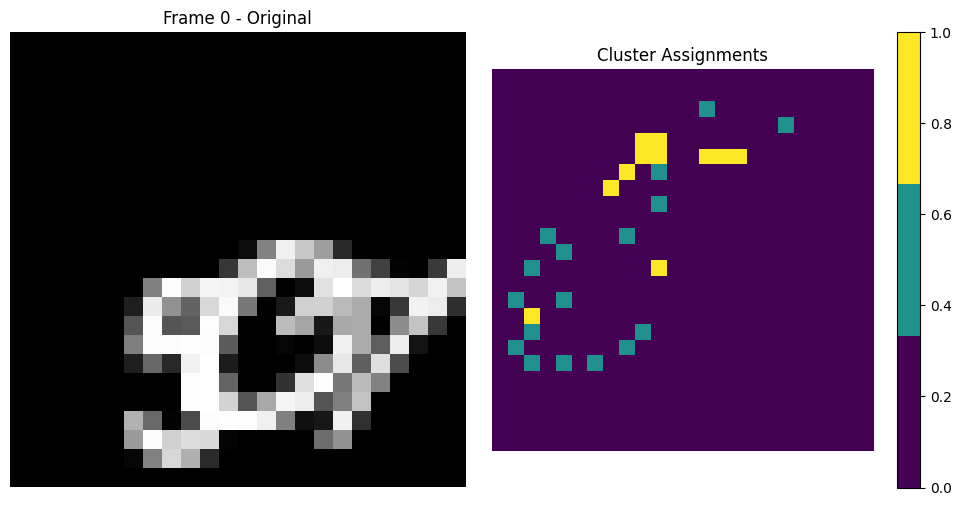

  Nouveau meilleur AMI : 0.0286


In [ ]:
# 11. Boucle d'entrainement
n_iterations            = 100
best_ami                = -1
patience                = 0
max_patience            = 5
validation_frequency    = 50
visualization_frequency = 200
validation_samples      = 15

for epoch in range(n_iterations):
    train_ami_mean  = Mean()
    train_loss_mean = Mean()
    now = time.perf_counter()

    for step, (features, groups) in enumerate(train_data):
        checkpoint.step.assign_add(1)
        lstm_h, lstm_c, preds, gamma = make_initial_state()

        for t in range(SEQUENCE_LENGTH):
            frame_t = features[:, t:t + 1, :, :, :]
            loss, lstm_h, lstm_c, preds, gamma, current_lr = train_step_frame(
                frame_t, lstm_h, lstm_c, preds, gamma)

        train_loss_mean(loss)
        ami_train = ami_score(gamma, groups[:, -1:, :, :, :])
        train_ami_mean(ami_train)

        if step % 10 == 0:
            with summary_writer.as_default():
                tf.summary.scalar('train_loss',    loss,       step=checkpoint.step)
                tf.summary.scalar('train_ami',     ami_train,  step=checkpoint.step)
                tf.summary.scalar('learning_rate', current_lr, step=checkpoint.step)

        if step % validation_frequency == 0:
            tloss      = train_loss_mean.result()
            tami_score = train_ami_mean.result()
            train_loss_mean.reset_state()
            train_ami_mean.reset_state()

            vami_score = validation(valid_data.take(validation_samples))
            gc.collect()

            with summary_writer.as_default():
                tf.summary.scalar('validation_ami', vami_score, step=checkpoint.step)

            duration = time.perf_counter() - now
            print(f'Epoch {epoch+1} | Step {step+1} | '
                  f'loss={tloss.numpy():.4f} | '
                  f't_ami={tami_score:.4f} | '
                  f'v_ami={vami_score.numpy():.4f} | '
                  f'lr={current_lr:.6f} | '
                  f'{duration:.1f}s')

            if step % visualization_frequency == 0:
                try:
                    visualize_clusters(gamma, features, epoch, step)
                except Exception as e:
                    print(f'Visualisation ignoree : {e}')

            if vami_score.numpy() > checkpoint.ami:
                checkpoint.ami.assign(vami_score)
                checkpoint_manager.save()
                patience = 0
                if vami_score.numpy() > best_ami:
                    best_ami = vami_score.numpy()
                    print(f'  Nouveau meilleur AMI : {best_ami:.4f}')
            else:
                patience += 1

            now = time.perf_counter()

    if patience >= max_patience:
        print(f'Early stopping apres {epoch + 1} epochs')
        break

print(f'Entrainement termine. Meilleur AMI : {best_ami:.4f}')